# Cell 1: Setup and physicochemical descriptors

In [1]:
# Cell 1: Load data and extract physicochemical descriptors

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski

# Load the B3DB dataset
df = pd.read_csv('../data/B3DB_classification.tsv', sep='\t')

# Keep only molecules with continuous logBB values (for regression)
df_reg = df[df['logBB'].notna()].copy().reset_index(drop=True)
print(f"Molecules with continuous logBB: {len(df_reg)}")

# Extract Abraham-like physicochemical descriptors
def compute_descriptors(smiles):
    """Compute a set of physicochemical descriptors relevant to membrane permeability."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return pd.Series({
        'MW': Descriptors.MolWt(mol),              # Molecular weight — diffusion cost
        'logP': Crippen.MolLogP(mol),              # Octanol-water partition — hydrophobicity
        'TPSA': Descriptors.TPSA(mol),             # Topological polar surface area
        'HBD': Lipinski.NumHDonors(mol),           # H-bond donors — desolvation penalty
        'HBA': Lipinski.NumHAcceptors(mol),        # H-bond acceptors
        'RotB': Lipinski.NumRotatableBonds(mol),   # Flexibility — conformational entropy
        'MolarRefractivity': Crippen.MolMR(mol),   # Polarizability / size proxy
    })

print("\nComputing descriptors...")
desc_df = df_reg['SMILES'].apply(compute_descriptors)
df_reg = pd.concat([df_reg, desc_df], axis=1)

# Drop any rows where descriptor calculation failed
df_reg = df_reg.dropna(subset=['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotB', 'MolarRefractivity'])
print(f"After descriptor calculation: {len(df_reg)} molecules")

# Preview
df_reg[['compound_name', 'SMILES', 'logBB', 'MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotB']].head()

Molecules with continuous logBB: 1058

Computing descriptors...
After descriptor calculation: 1058 molecules


,compound_name,SMILES,logBB,MW,logP,TPSA,HBD,HBA,RotB
0,sulphasalazine,O=C(O)c1cc(N=Nc2ccc(S(=O)(=O)Nc3ccccn3)cc2)ccc1O,-2.69,398.400,3.70160,141.31,3.0,7.0,6.0
1,moxalactam,COC1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C(=O)...,-2.52,520.480,-1.12770,206.30,4.0,11.0,9.0
2,clioquinol,Oc1c(I)cc(Cl)c2cccnc12,-2.40,305.502,3.19840,33.12,1.0,2.0,0.0
3,bbcpd11 (cimetidine analog) (y-g13),CCNC(=NCCSCc1ncccc1Br)NC#N,-2.15,342.266,2.11348,73.10,2.0,4.0,6.0
4,schembl614298,CN1CC[C@]23c4c5ccc(OC6O[C@H](C(=O)O)[C@@H](O)[...,-2.15,461.467,-1.23650,149.15,5.0,9.0,3.0


# Cell 2: LFER-style linear regression

In [2]:
# Cell 2: Fit a linear free energy relationship (LFER) model

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Features (physicochemical descriptors) and target (logBB)
feature_cols = ['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotB', 'MolarRefractivity']
X = df_reg[feature_cols].values
y = df_reg['logBB'].values

# Standardize features so coefficients are directly comparable
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split (same random seed for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Train set: {X_train.shape[0]} molecules")
print(f"Test set:  {X_test.shape[0]} molecules")

# Fit LFER linear model
lfer = LinearRegression()
lfer.fit(X_train, y_train)

# Predict on test set
y_pred_lfer = lfer.predict(X_test)

# Report performance
r2 = r2_score(y_test, y_pred_lfer)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lfer))

print(f"\nLFER Test Performance:")
print(f"  R²   = {r2:.3f}")
print(f"  RMSE = {rmse:.3f}")

# The physical story: coefficients on standardized features
print(f"\nLFER Coefficients (on standardized descriptors):")
print(f"  {'Intercept':<20s}: {lfer.intercept_:+.3f}")
for name, coef in zip(feature_cols, lfer.coef_):
    print(f"  {name:<20s}: {coef:+.3f}")

Train set: 846 molecules
Test set:  212 molecules

LFER Test Performance:
  R²   = 0.217
  RMSE = 0.666

LFER Coefficients (on standardized descriptors):
  Intercept           : -0.056
  MW                  : +0.141
  logP                : -0.080
  TPSA                : -0.819
  HBD                 : +0.155
  HBA                 : +0.097
  RotB                : -0.090
  MolarRefractivity   : +0.221


# Cell 2.5: Diagnostic — correlation and regularization

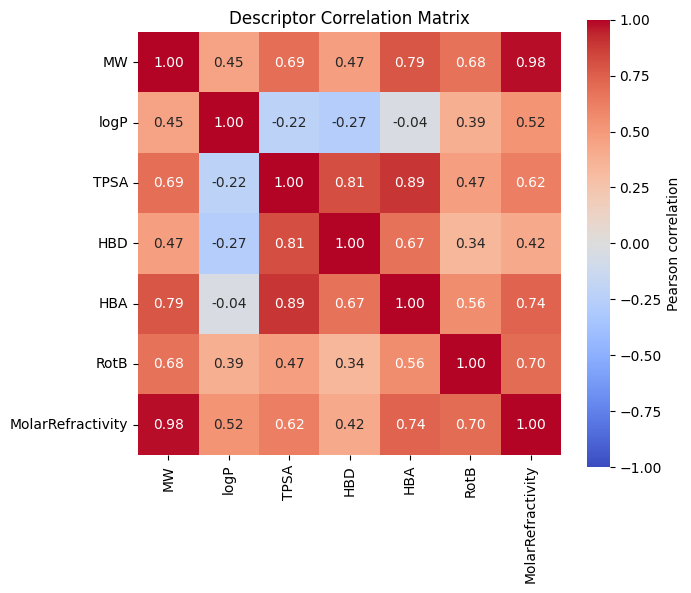


Ridge Regression (alpha = 1.0):
  R²   = 0.218
  RMSE = 0.666

Ridge Coefficients (on standardized descriptors):
  Intercept           : -0.056
  MW                  : +0.138
  logP                : -0.075
  TPSA                : -0.806
  HBD                 : +0.151
  HBA                 : +0.093
  RotB                : -0.090
  MolarRefractivity   : +0.217


In [3]:
# Cell 2.5: Diagnose multicollinearity and apply regularized regression

import seaborn as sns
from sklearn.linear_model import Ridge, RidgeCV

# Correlation heatmap of descriptors
corr = df_reg[feature_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, vmin=-1, vmax=1, ax=ax,
            cbar_kws={'label': 'Pearson correlation'})
ax.set_title('Descriptor Correlation Matrix')
plt.tight_layout()
plt.savefig('../results/descriptor_correlation.png', dpi=150)
plt.show()

# Ridge regression with cross-validated alpha (handles multicollinearity)
ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"\nRidge Regression (alpha = {ridge.alpha_}):")
print(f"  R²   = {r2_ridge:.3f}")
print(f"  RMSE = {rmse_ridge:.3f}")

print(f"\nRidge Coefficients (on standardized descriptors):")
print(f"  {'Intercept':<20s}: {ridge.intercept_:+.3f}")
for name, coef in zip(feature_cols, ridge.coef_):
    print(f"  {name:<20s}: {coef:+.3f}")

# Cell 3: Hybrid physics + ML residual model

In [4]:
# Cell 3: Hybrid model — LFER baseline + ML residual correction

from sklearn.ensemble import RandomForestRegressor
from rdkit.Chem import rdFingerprintGenerator

# Step 1: LFER predicts on training set, compute residuals
y_train_lfer_pred = lfer.predict(X_train)
train_residuals = y_train - y_train_lfer_pred

# Step 2: Generate Morgan fingerprints for all molecules
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return np.array(morgan_gen.GetFingerprint(mol))

print("Computing Morgan fingerprints...")
fingerprints = df_reg['SMILES'].apply(smiles_to_fp)
X_fp = np.vstack(fingerprints.values)

# Split fingerprints with the SAME train/test indices as before
train_idx, test_idx = train_test_split(
    np.arange(len(df_reg)), test_size=0.2, random_state=42
)
X_fp_train = X_fp[train_idx]
X_fp_test = X_fp[test_idx]

# Step 3: Train RF to predict residuals
print("Training residual correction model (Random Forest on Morgan fingerprints)...")
rf_residual = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_residual.fit(X_fp_train, train_residuals)

# Step 4: Hybrid prediction on test set = LFER + ML residual
test_residual_pred = rf_residual.predict(X_fp_test)
y_pred_hybrid = y_pred_lfer + test_residual_pred

# Also train a pure RF on fingerprints (for comparison)
rf_pure = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_pure.fit(X_fp_train, y_train)
y_pred_pure_rf = rf_pure.predict(X_fp_test)

# Compare three models
results = pd.DataFrame({
    'Model': ['LFER (physics only)', 'Pure RF (ML only)', 'Hybrid (physics + ML residual)'],
    'R²': [
        r2_score(y_test, y_pred_lfer),
        r2_score(y_test, y_pred_pure_rf),
        r2_score(y_test, y_pred_hybrid)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lfer)),
        np.sqrt(mean_squared_error(y_test, y_pred_pure_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_hybrid))
    ],
    'Interpretability': ['High', 'Low', 'Medium (physics part)']
})

print("\n" + "="*70)
print("Three-model comparison:")
print("="*70)
print(results.to_string(index=False))

Computing Morgan fingerprints...
Training residual correction model (Random Forest on Morgan fingerprints)...

Three-model comparison:
                         Model       R²     RMSE      Interpretability
           LFER (physics only) 0.217280 0.666295                  High
             Pure RF (ML only) 0.470897 0.547814                   Low
Hybrid (physics + ML residual) 0.511519 0.526366 Medium (physics part)


# Cell 4: Visualize three-model comparison

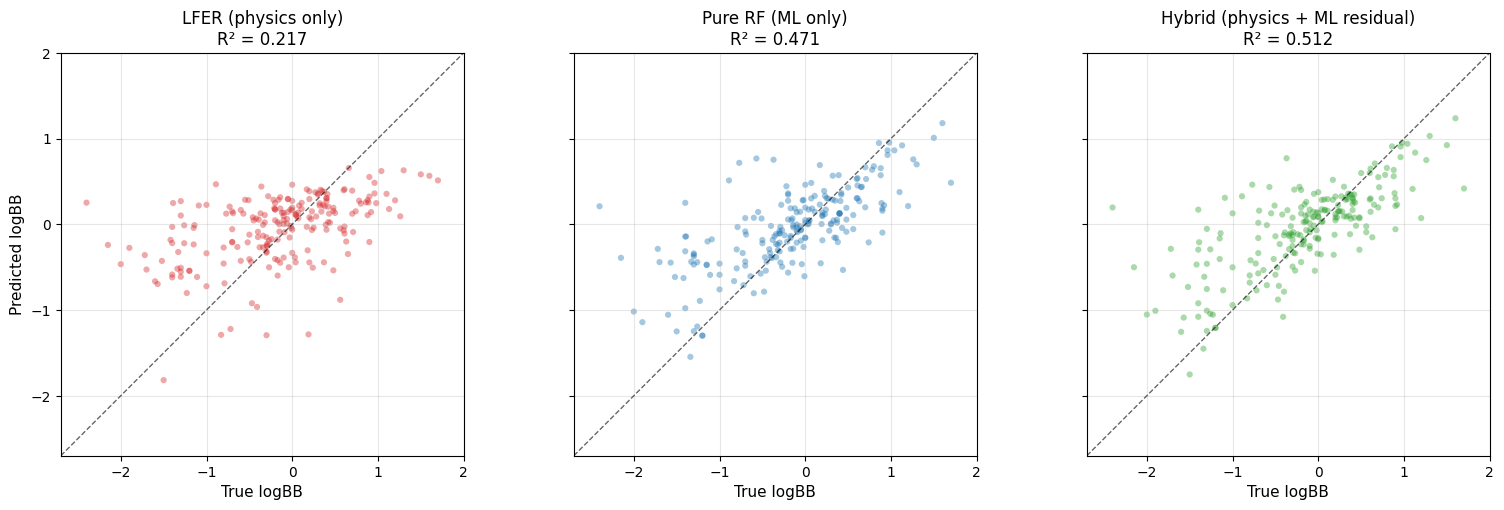

In [5]:
# Cell 4: Visualize three-model comparison

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, sharex=True)

models = [
    ('LFER (physics only)', y_pred_lfer, 0.217),
    ('Pure RF (ML only)', y_pred_pure_rf, 0.471),
    ('Hybrid (physics + ML residual)', y_pred_hybrid, 0.512),
]

colors = ['#d62728', '#1f77b4', '#2ca02c']  # red, blue, green

for ax, (name, y_pred, r2), color in zip(axes, models, colors):
    ax.scatter(y_test, y_pred, alpha=0.4, s=20, color=color, edgecolor='none')
    
    # Diagonal (perfect prediction)
    lo, hi = y_test.min() - 0.3, y_test.max() + 0.3
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.6)
    
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel('True logBB', fontsize=11)
    ax.set_title(f'{name}\nR² = {r2:.3f}', fontsize=12)
    ax.grid(alpha=0.3)
    ax.set_aspect('equal')

axes[0].set_ylabel('Predicted logBB', fontsize=11)

plt.tight_layout()
plt.savefig('../results/three_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Cell 5: Residual analysis

Top 10 molecules where LFER fails most:
                      compound_name                                                                                                                                                             SMILES  logBB_true  logBB_pred_lfer  residual_lfer      MW    logP   TPSA  HBD  HBA
                         clioquinol                                                                                                                                             Oc1c(I)cc(Cl)c2cccnc12       -2.40         0.252403      -2.652403 305.502 3.19840  33.12  1.0  2.0
bbcpd11 (cimetidine analog) (y-g13)                                                                                                                                         CCNC(=NCCSCc1ncccc1Br)NC#N       -2.15        -0.240944      -1.909056 342.266 2.11348  73.10  2.0  4.0
                              tz-17                                                                                                 

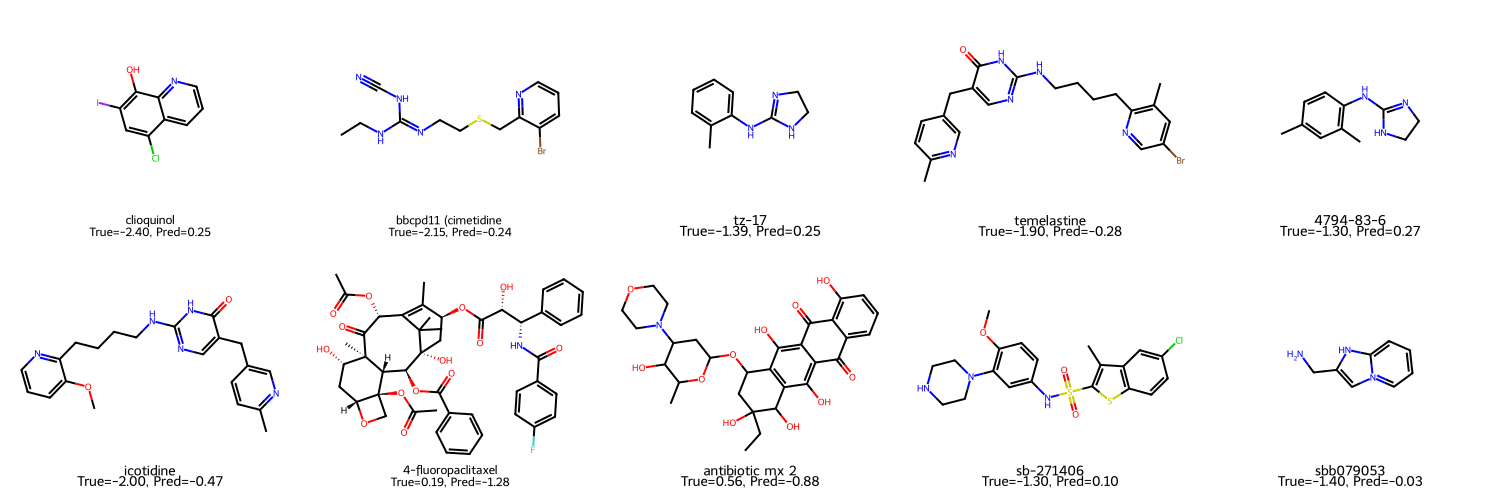

In [7]:
# Cell 5: Residual analysis — where does physics fail most?

from rdkit.Chem import Draw

# Put test results into a DataFrame
test_df = df_reg.iloc[test_idx].copy().reset_index(drop=True)
test_df['logBB_true'] = y_test
test_df['logBB_pred_lfer'] = y_pred_lfer
test_df['residual_lfer'] = y_test - y_pred_lfer
test_df['abs_residual_lfer'] = np.abs(test_df['residual_lfer'])

# Top-10 worst LFER predictions (by absolute residual)
worst = test_df.nlargest(10, 'abs_residual_lfer')[
    ['compound_name', 'SMILES', 'logBB_true', 'logBB_pred_lfer', 'residual_lfer',
     'MW', 'logP', 'TPSA', 'HBD', 'HBA']
]

print("Top 10 molecules where LFER fails most:")
print("="*80)
print(worst.to_string(index=False))

# Visualize their structures
mols = [Chem.MolFromSmiles(s) for s in worst['SMILES']]
legends = [f"{name[:20]}\nTrue={true:.2f}, Pred={pred:.2f}" 
           for name, true, pred in zip(worst['compound_name'], 
                                        worst['logBB_true'],
                                        worst['logBB_pred_lfer'])]

img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(300, 250), 
                            legends=legends, useSVG=False, returnPNG=False)
img.save('../results/lfer_worst_predictions.png')
img